NOME: Hercules André

Atividade 02 - Exercicio 05
Starting from the point x=[1.0,1.0], Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2

Ponto inicial: x = [1.0,1.0]

Importar as Bibliotecas

In [1]:
using Pkg
Pkg.add("LinearAlgebra")



   Resolving package versions...
     Project No packages added to or removed from `C:\Users\hercules.andre\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\hercules.andre\.julia\environments\v1.12\Manifest.toml`


In [2]:
using LinearAlgebra

In [3]:
using Plots

In [4]:
# Função
function f(x)
    return 10*(x[1] - 3)^2 + 2*(x[2] - 2)^2
end

# Gradiente
function grad_f(x)
    return [20*(x[1] - 3),
            4*(x[2] - 2)]
end

# Hessiana
function hess_f(x)
    return [20 0;
            0  4]
end

hess_f (generic function with 1 method)

Gradient Descent

In [5]:
function gradient_descent(x0; α=0.1, tol=1e-6, max_iter=100)
    x = x0
    path = [x]

    for k in 1:max_iter
        g = grad_f(x)
        x_new = x - α * g

        push!(path, x_new)

        if norm(x_new - x) < tol
            println("Convergiu em ", k, " iterações")
            return x_new, path
        end

        x = x_new
    end

    println("Não convergiu")
    return x, path
end

gradient_descent (generic function with 1 method)

Executar

In [6]:
x0 = [1.0, 1.0]

x_gd, path_gd = gradient_descent(x0, α=0.1)

println("Mínimo GD: ", x_gd)

Não convergiu
Mínimo GD: [1.0, 1.9999999999999998]


Método de Newton

In [7]:
function newton_method(x0; tol=1e-6, max_iter=10)
    x = x0
    path = [x]

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)

        x_new = x - H \ g   # resolve H*d = g

        push!(path, x_new)

        if norm(x_new - x) < tol
            println("Convergiu em ", k, " iterações")
            return x_new, path
        end

        x = x_new
    end

    println("Finalizou")
    return x, path
end

newton_method (generic function with 1 method)

Executar

In [9]:
x_newton, path_newton = newton_method(x0)

println("Mínimo Newton: ", x_newton)

Convergiu em 2 iterações
Mínimo Newton: [3.0, 2.0]


Contorno + Caminhos

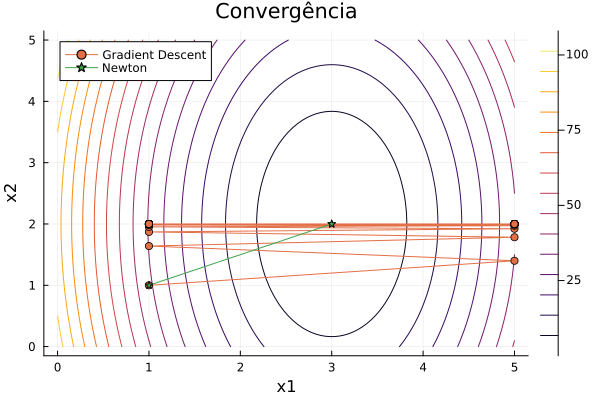

In [11]:
x1 = range(0, 5, length=100)
x2 = range(0, 5, length=100)

z = [f([i, j]) for i in x1, j in x2]

contour(x1, x2, z', title="Convergência", xlabel="x1", ylabel="x2")

# Caminho GD
plot!([p[1] for p in path_gd], [p[2] for p in path_gd],
      marker=:circle, label="Gradient Descent")

# Caminho Newton
plot!([p[1] for p in path_newton], [p[2] for p in path_newton],
      marker=:star, label="Newton")